# Redes Neuronales Recurrentes

En este notebook exploraremos distintas arquitecturas de redes neuronales aplicadas a datos del mundo real. Hasta ahora hemos trabajado siempre con el mismo tipo de modelo: el **Perceptrón Multicapa** (MLP), una red *feed-forward* de la que ya conocemos bien su estructura y funcionamiento.

![](https://www.researchgate.net/profile/Mohamed_Zahran6/publication/303875065/figure/fig4/AS:371118507610123@1465492955561/A-hypothetical-example-of-Multilayer-Perceptron-Network.png)

El MLP es un modelo poderoso y versátil, pero tiene una limitación importante: no está diseñado para capturar dependencias temporales en **datos secuenciales**, como series de precios financieros. En este notebook trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene el historial del tipo de cambio **dólar estadounidense / rublo ruso (USD/RUB)**. Este tipo de datos, en el que cada observación depende de las anteriores, requiere una arquitectura diferente: las **Redes Neuronales Recurrentes** (RNN).


## Definición

En una red neuronal *feed forward* la información viaja en un único sentido: desde la capa de entrada hacia la salida, sin volver atrás. El `MLP` es el ejemplo por excelencia de este tipo. En cambio, una **red recurrente** añade conexiones hacia atrás entre las neuronas, permitiendo que la información de pasos anteriores influya en el procesamiento actual.

![](https://miro.medium.com/max/2544/1*aIT6tmnk3qHpStkOX3gGcQ.png)


La imagen anterior muestra la `RNN` más simple posible: una entrada, una neurona oculta y una salida. En un `MLP` estándar, la salida se calcula como:

$$ \mathbf{y} = \mathbf{W}_y \mathbf{h} = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}) $$

En una `RNN`, además de la entrada $\mathbf{x}_t$ del instante actual, se incorpora también el estado oculto del instante anterior $\mathbf{h}_{t-1}$, con su propia matriz de pesos:

$$ \mathbf{y}_t = \mathbf{W}_y \mathbf{h}_t = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_h \mathbf{h}_{t-1}) $$

En nuestro caso, el dataset USD/RUB está compuesto por una secuencia de precios diarios. Cada elemento $\mathbf{x}_t$ representa el precio (y otras características) del día $t$, y la red deberá aprender a utilizar el contexto de los días anteriores para predecir el valor del día siguiente.


## Tipos de RNNs


Las `RNN` abren un nuevo abanico de posibilidades según cómo configuremos las entradas y salidas:

![](https://i.stack.imgur.com/b4sus.jpg)

La configuración *one-to-one* equivale al `MLP` clásico. Las demás permiten trabajar con secuencias: *many-to-one* es ideal para predecir un único valor futuro a partir de una ventana de valores pasados (que es exactamente lo que haremos con el precio USD/RUB), mientras que *many-to-many* permite predecir varios pasos hacia el futuro de forma simultánea.


## Entrenando RNNs

El entrenamiento de las `RNN` sigue el mismo algoritmo que ya conocemos: **backpropagation**. La diferencia es que ahora los gradientes pueden fluir desde múltiples salidas a lo largo del tiempo, lo que se conoce como *backpropagation through time* (BPTT). Esto puede provocar problemas como el **desvanecimiento** o la **explosión del gradiente**, de los que hablaremos más adelante.

![](https://s3.ap-south-1.amazonaws.com/techleer/191.png)

En la práctica, frameworks como PyTorch ya manejan este proceso internamente, por lo que podemos entrenar una `RNN` con los mismos ingredientes que usamos para el `MLP`: un optimizador, una función de pérdida y el bucle de entrenamiento habitual.


## Predicción de series temporales

Ahora que ya tenemos la base teórica, vamos a aplicarla a un problema real. Trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene precios históricos diarios del tipo de cambio dólar/rublo.Cargaremos los datos, los normalizaremos y construiremos ventanas deslizantes de `n_steps` días para predecir el precio del día siguiente.


In [146]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            if ix >= len(series):
                break
            s = series[ix, :, 0]
            plt.plot(s, ".-")
            if y is not None:
                plt.plot([len(s)], y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot([len(s)], y_pred[ix], "ro")
            plt.grid(True)
            plt.hlines(0, 0, len(s) + 2, linewidth=1)
            plt.axis([0, len(s) + 2, -1, 1])
            if row == r - 1:
                plt.xlabel(x_label if x_label else "Paso de tiempo", fontsize=12)
            if col == 0:
                plt.ylabel(y_label if y_label else "Precio", fontsize=12, rotation=0, labelpad=40)

    legend_items = [Line2D([0], [0], color='steelblue', marker='.', linestyle='-', label='Historial de precios')]
    if y is not None:
        legend_items.append(Line2D([0], [0], color='blue', marker='x', linestyle='None', markersize=10, label='Precio real del día siguiente'))
    if y_pred is not None:
        legend_items.append(Line2D([0], [0], color='red', marker='o', linestyle='None', markersize=6, label='Predicción del modelo'))
    fig.legend(handles=legend_items, loc='lower center', ncol=len(legend_items), fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.suptitle("Ventanas de series temporales — USD/RUB", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

---

### Dataset real: USD/RUB

Una vez visto el ejemplo con datos sintéticos, replicamos el mismo flujo pero ahora con el dataset `USD_RUB_Historical_Data.csv`. Las series ya no son señales sinusoidales controladas, sino el precio histórico real del tipo de cambio dólar/rublo, lo que introduce mayor irregularidad y ruido real de mercado.


In [147]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('USD_RUB_Historical_Data.csv')
df = df.drop(columns=['Vol.'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")


        Date    Price     Open     High      Low  Change %
0 2006-01-02  28.7389  28.7414  28.7414  28.7414      0.00
1 2006-01-03  28.7389  28.7414  28.7414  28.7414      0.00
2 2006-01-04  28.7389  28.7414  28.7414  28.7414      0.00
3 2006-01-05  28.6650  28.7320  28.7320  28.6700     -0.26
4 2006-01-06  28.6650  28.6700  28.6700  28.6700      0.00

Shape: (5000, 6)

Columnas: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %']


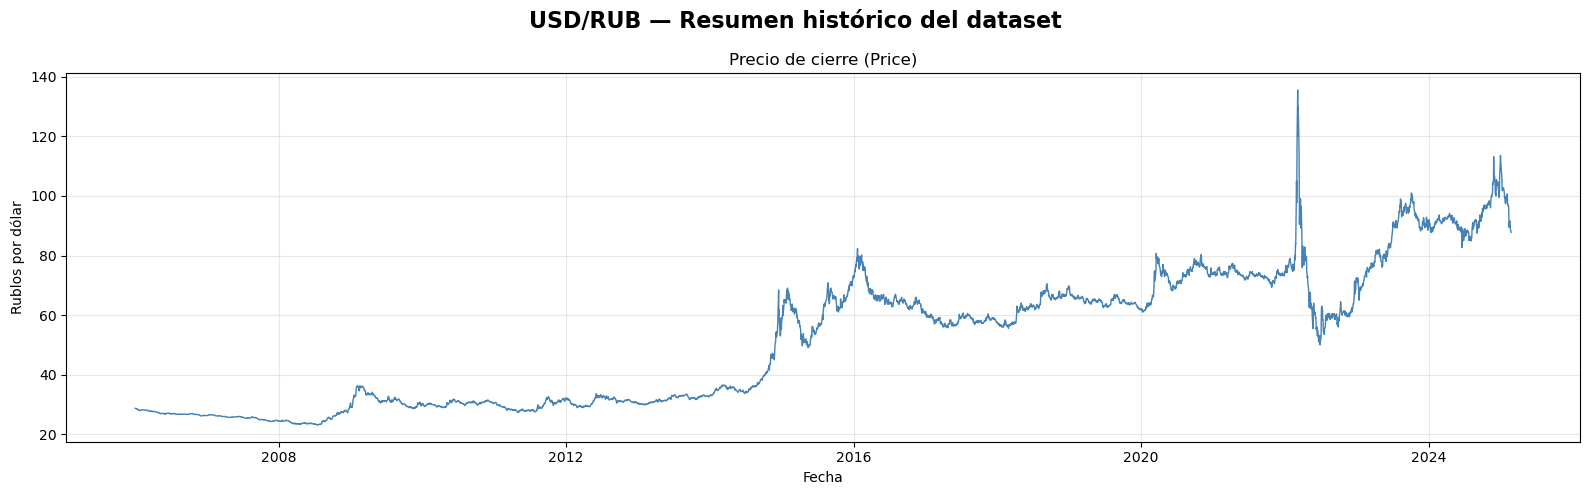

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle('USD/RUB — Resumen histórico del dataset', fontsize=16, fontweight='bold')

ax.plot(df['Date'], df['Price'], color='steelblue', linewidth=1)
ax.set_title('Precio de cierre (Price)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Rublos por dólar')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
scaler = MinMaxScaler()
features = ['Price','Open','High','Low','Change %']
data = scaler.fit_transform(df[features])

n_steps = 50

def create_sequences(data, n_steps, target_idx=0):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps, target_idx])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32).reshape(-1, 1))

sequences, targets = create_sequences(data, n_steps)

n = len(sequences)
n_train = int(0.7 * n)
n_valid = int(0.2 * n)

X_train, y_train = sequences[:n_train],               targets[:n_train]
X_valid, y_valid = sequences[n_train:n_train+n_valid], targets[n_train:n_train+n_valid]
X_test,  y_test  = sequences[n_train+n_valid:],        targets[n_train+n_valid:]

print(f"Train: {X_train.shape},  {y_train.shape}")
print(f"Valid: {X_valid.shape},  {y_valid.shape}")
print(f"Test:  {X_test.shape},   {y_test.shape}")


Train: (3465, 50, 5),  (3465, 1)
Valid: (990, 50, 5),  (990, 1)
Test:  (495, 50, 5),   (495, 1)


In [150]:
print(df.describe())


                             Date        Price         Open         High  \
count                        5000  5000.000000  5000.000000  5000.000000   
mean   2015-07-30 18:23:02.400000    51.774307    51.884265    52.442204   
min           2006-01-02 00:00:00    23.153100    23.157400    23.203500   
25%           2010-10-17 06:00:00    30.321325    30.316250    30.464400   
50%           2015-08-01 12:00:00    56.803900    56.931150    57.286650   
75%           2020-05-12 06:00:00    68.037675    68.180625    68.988325   
max           2025-02-24 00:00:00   135.500000   135.500000   158.300000   
std                           NaN    22.630656    22.741387    23.259093   

               Low     Change %  
count  5000.000000  5000.000000  
mean     51.368729     0.029896  
min      23.055000   -13.540000  
25%      30.181350    -0.400000  
50%      56.402200     0.000000  
75%      67.280500     0.410000  
max     125.500000    20.430000  
std      22.275896     1.233102  


Nuestro objetivo es **predecir el precio de cierre del día siguiente** a partir de los `n_steps` días anteriores. Si un modelo logra hacer esto con precisión, podría ser útil como señal en estrategias de análisis financiero o para monitorear la volatilidad del tipo de cambio USD/RUB.


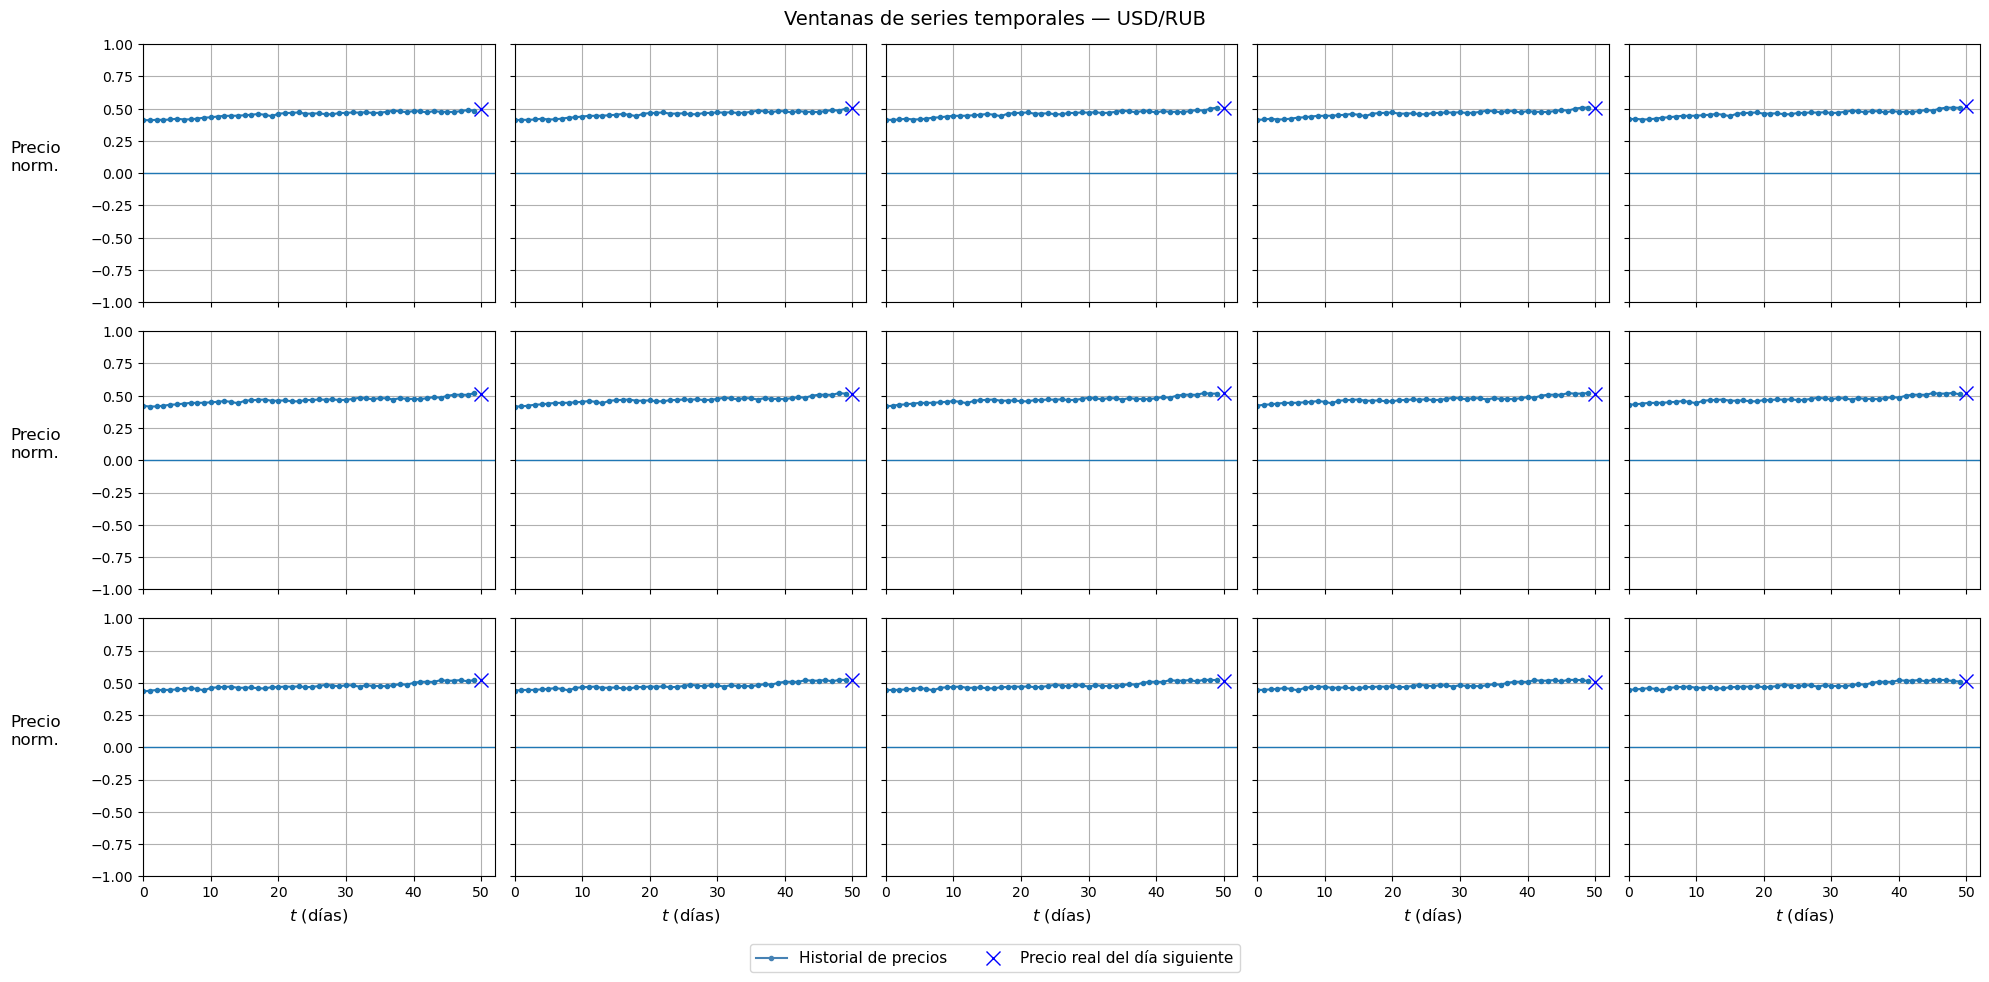

In [151]:
# Visualizar 15 ventanas del conjunto de prueba USD/RUB con su valor objetivo (cruz azul)
# El eje Y muestra el precio normalizado [0, 1]; la 'x' azul es el precio real del día siguiente
plot_series(X_test, y_test, x_label="$t$ (días)", y_label="Precio\nnorm.")


### Predicción *Naive*

Un modelo de referencia muy sencillo consiste en predecir que el precio del día siguiente será igual al precio del último día conocido. A pesar de su simplicidad, este modelo puede ser difícil de superar en series financieras con poca volatilidad a corto plazo.


In [152]:
from sklearn.metrics import mean_squared_error

# Predicción naive: el precio del día siguiente = último precio conocido de la ventana
y_pred_naive = X_test[:, -1, 0].reshape(-1, 1)
mean_squared_error(y_test, y_pred_naive)


0.00011829176946775988

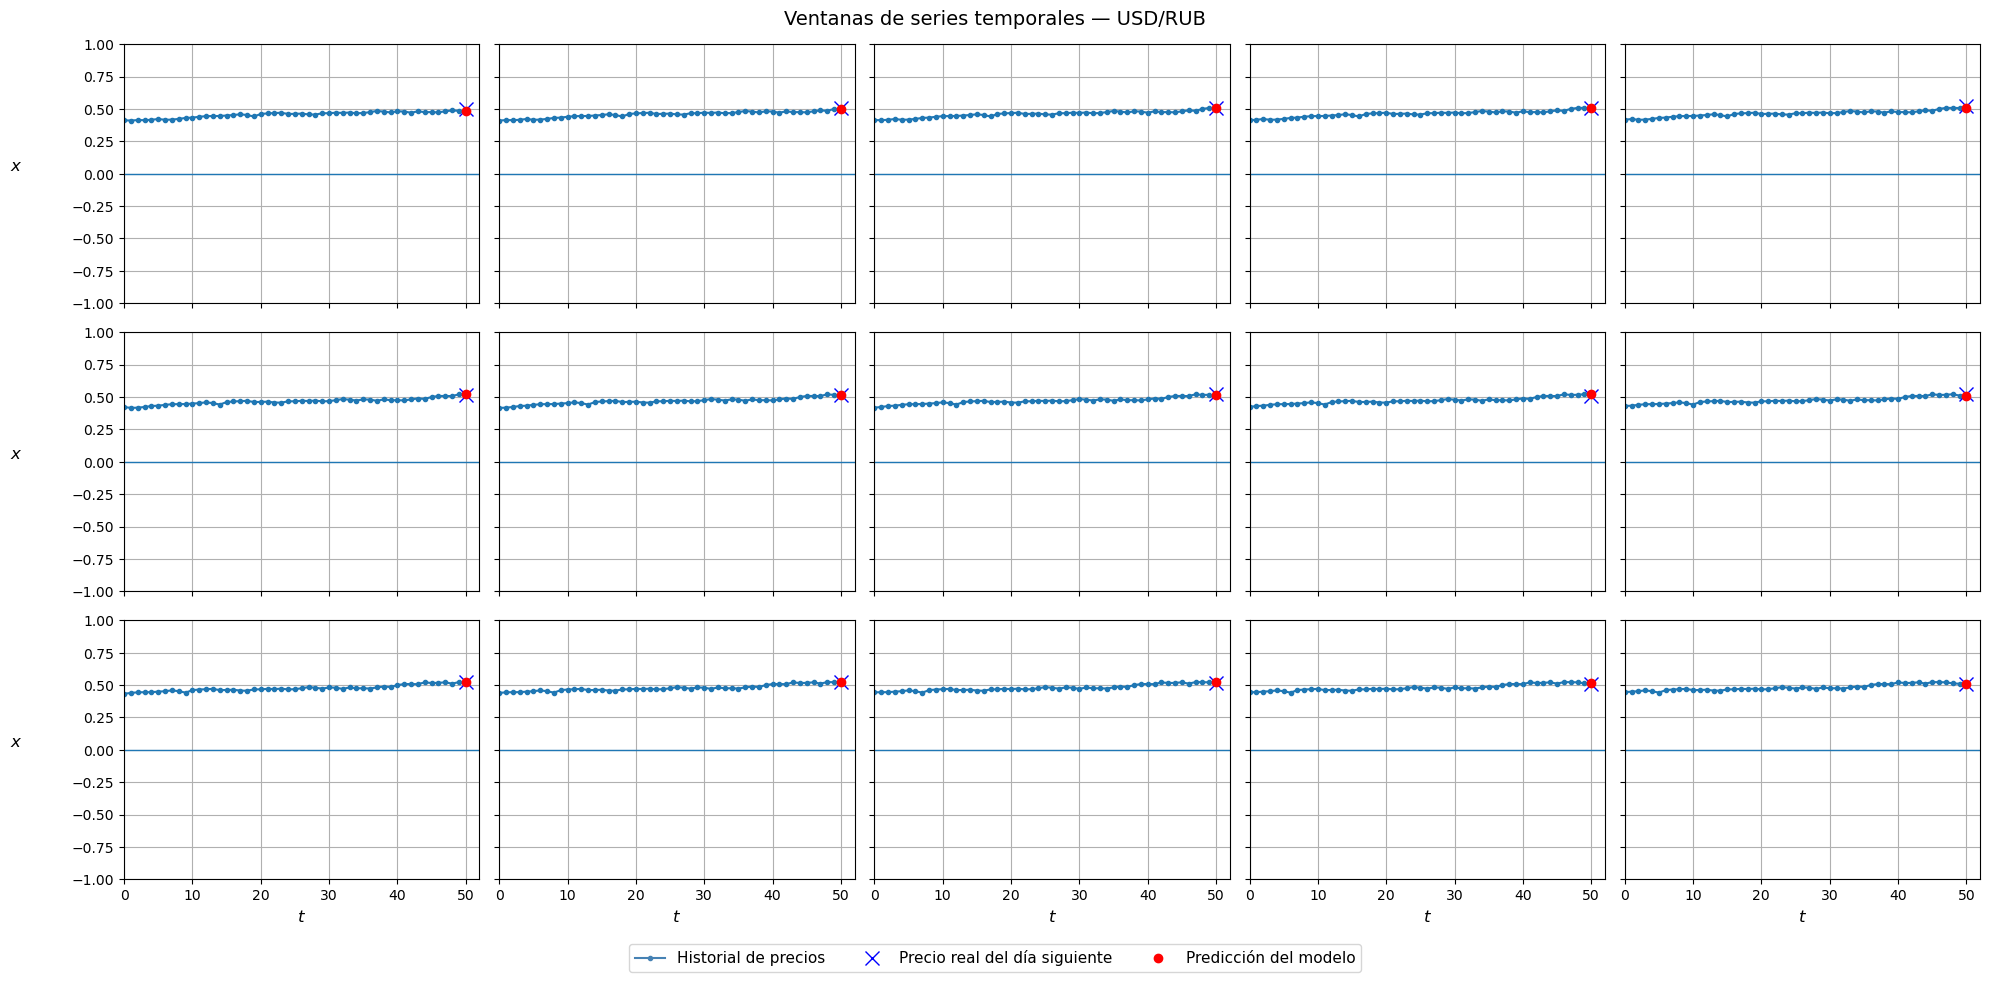

In [153]:
plot_series(X_test, y_test, y_pred_naive)


Como se puede ver, este modelo tan simple tiene un rendimiento razonable: en series financieras, el precio del día anterior suele ser una buena estimación del precio del día siguiente. Este resultado es el **umbral mínimo** que cualquier modelo más complejo debería superar.


### Perceptrón Multicapa

Dado que todas las ventanas tienen la misma longitud (`n_steps`), podemos intentar resolver el problema con un `MLP` estándar. Aunque no captura dependencias temporales de forma explícita, puede aprender correlaciones lineales útiles si los patrones son suficientemente regulares.


In [154]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval': TimeSeriesDataset(X_valid, y_valid),
    'test': TimeSeriesDataset(X_test, y_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True, batch_size=64),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=64),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=64)
}

In [155]:
class MLP(torch.nn.Module):
  def __init__(self, n_steps=50, n_features=5, n_out=1):
    super().__init__()
    self.fc = torch.nn.Linear(n_steps * n_features, n_out)

  def forward(self, x):
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

mlp = MLP(n_steps=n_steps, n_features=X_train.shape[2])
mlp

MLP(
  (fc): Linear(in_features=250, out_features=1, bias=True)
)

In [156]:
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, dataloader, epochs=150, scheduler=None, early_stopping=0):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    best_loss, step = float('inf'), 0
    
    for epoch in bar:
        model.train()
        train_loss, train_acc = [], []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            train_acc.append((torch.abs(y_hat - y) < 0.02).float().mean().item())
        
        model.eval()
        eval_loss, eval_acc = [], []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                eval_acc.append((torch.abs(y_hat - y) < 0.02).float().mean().item())
        
        mean_train_loss = np.mean(train_loss)
        mean_eval_loss = np.mean(eval_loss)
        mean_train_acc = np.mean(train_acc)
        mean_eval_acc = np.mean(eval_acc)
        bar.set_description(f"loss {mean_train_loss:.5f} val_loss {mean_eval_loss:.5f} acc {mean_train_acc:.5f} val_acc {mean_eval_acc:.5f}")
        
        if mean_eval_loss < best_loss:
            best_loss = mean_eval_loss
            step = 0
        else:
            step += 1
        
        if scheduler:
            scheduler.step()
        if early_stopping and step > early_stopping:
            break

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

In [157]:
fit(mlp, dataloader)

loss 0.00006 val_loss 0.00087 acc 0.97188 val_acc 0.86302: 100%|██████████| 150/150 [00:14<00:00, 10.68it/s]


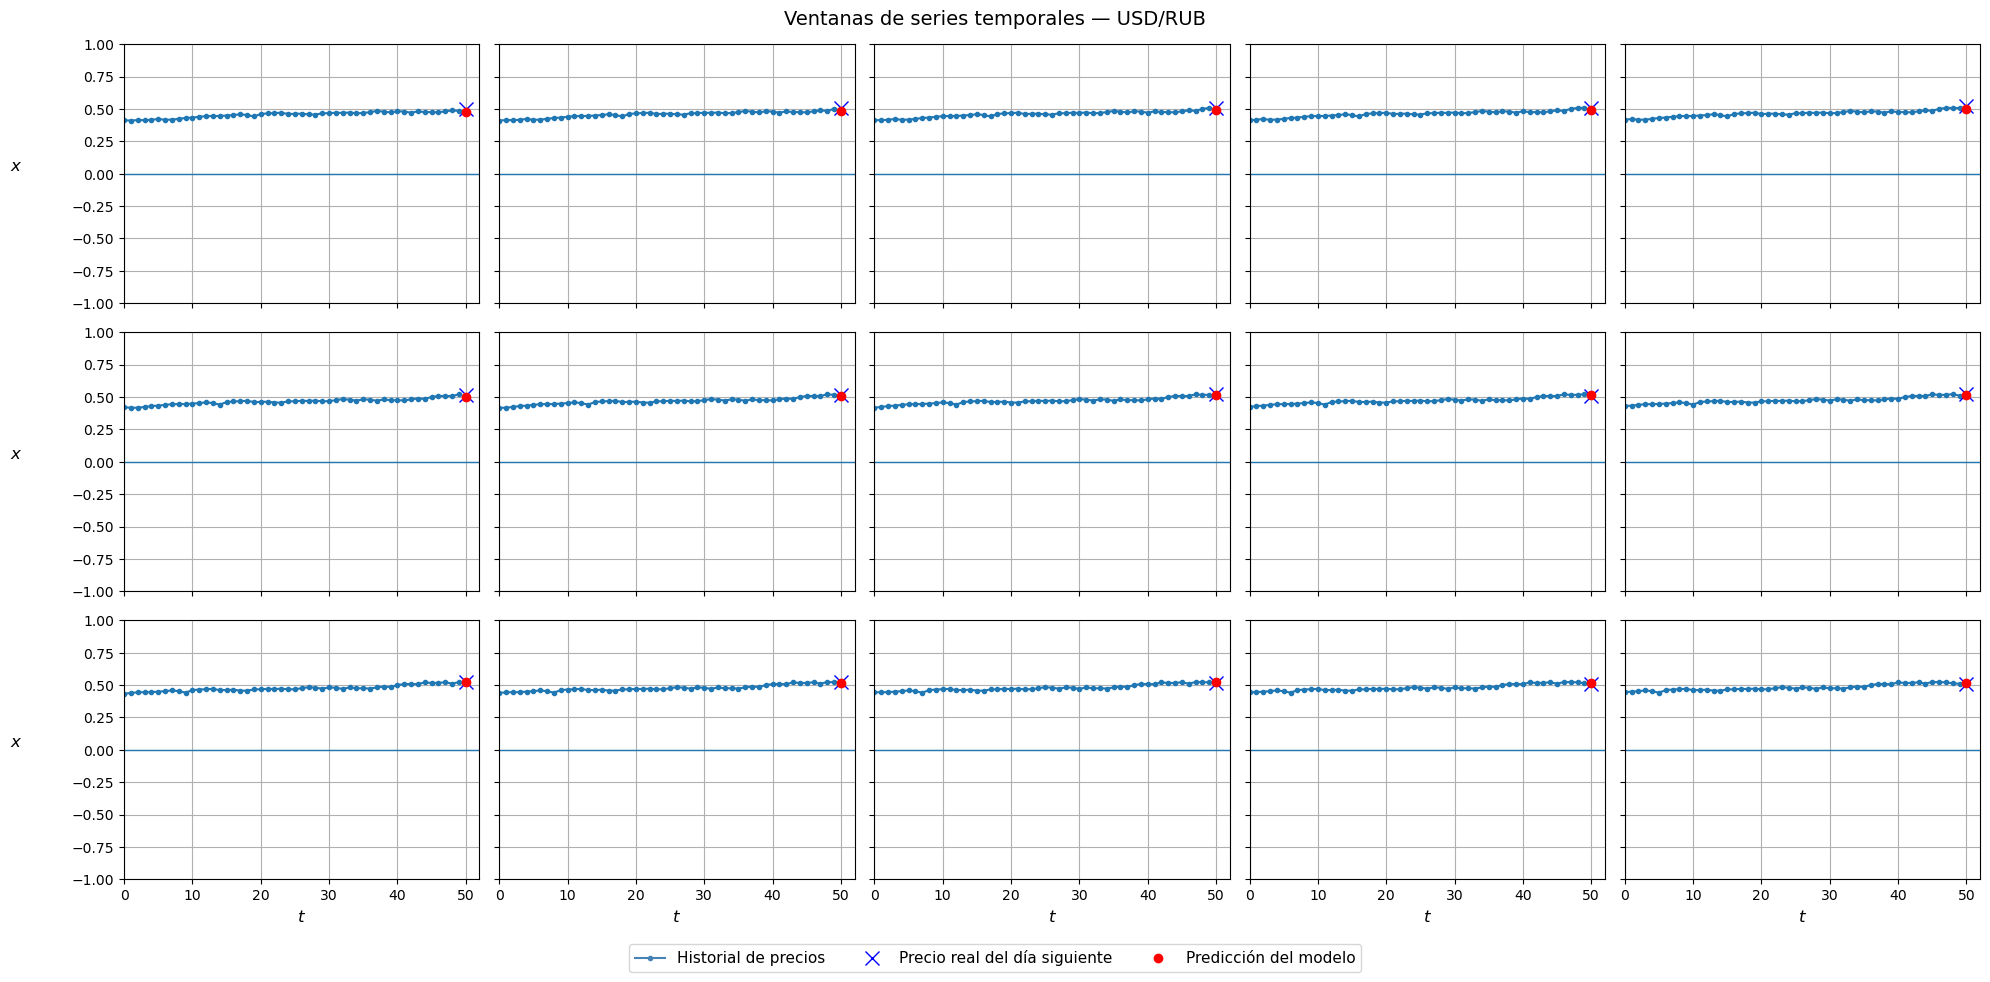

0.00030302791856229305

In [158]:
y_pred = predict(mlp, dataloader['test'])
plot_series(X_test, y_test, y_pred.cpu().numpy())
mean_squared_error(y_test, y_pred.cpu().numpy())


El `MLP` logra mejorar (o al menos igualar) la predicción ingenua.

## MLP *Many-to-Many*: Predicción a 30 días

Hasta ahora el MLP predecía **un solo día** hacia el futuro (*many-to-one*): tomaba una ventana de `n_steps` días y devolvía un único valor. Ahora vamos a extenderlo para que, a partir de esa misma ventana, prediga los **próximos 30 días** de precio en un solo paso (*many-to-many*). El cambio en la arquitectura es mínimo: solo ajustamos la capa de salida de 1 neurona a 30. Lo que sí cambia es cómo armamos las secuencias: el target ya no es un escalar sino un vector de 30 precios consecutivos.

In [159]:
n_horizon = 30

def create_sequences_m2m(data, n_steps, n_horizon, target_idx=0):
    X, y = [], []
    for i in range(len(data) - n_steps - n_horizon + 1):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps:i + n_steps + n_horizon, target_idx])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32))

seq_m2m, tgt_m2m = create_sequences_m2m(data, n_steps, n_horizon)

n_m2m      = len(seq_m2m)
n_train_m2m = int(0.7 * n_m2m)
n_valid_m2m = int(0.2 * n_m2m)

X_train_m2m, y_train_m2m = seq_m2m[:n_train_m2m],                          tgt_m2m[:n_train_m2m]
X_valid_m2m, y_valid_m2m = seq_m2m[n_train_m2m:n_train_m2m+n_valid_m2m],   tgt_m2m[n_train_m2m:n_train_m2m+n_valid_m2m]
X_test_m2m,  y_test_m2m  = seq_m2m[n_train_m2m+n_valid_m2m:],              tgt_m2m[n_train_m2m+n_valid_m2m:]

print(f"Train: {X_train_m2m.shape},  {y_train_m2m.shape}")
print(f"Valid: {X_valid_m2m.shape},  {y_valid_m2m.shape}")
print(f"Test:  {X_test_m2m.shape},   {y_test_m2m.shape}")

Train: (3444, 50, 5),  (3444, 30)
Valid: (984, 50, 5),  (984, 30)
Test:  (493, 50, 5),   (493, 30)


In [160]:
dataset_m2m = {
    'train': TimeSeriesDataset(X_train_m2m, y_train_m2m),
    'eval':  TimeSeriesDataset(X_valid_m2m, y_valid_m2m),
    'test':  TimeSeriesDataset(X_test_m2m,  y_test_m2m, train=False)
}

dataloader_m2m = {
    'train': DataLoader(dataset_m2m['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset_m2m['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset_m2m['test'],  shuffle=False, batch_size=64)
}

In [161]:
class MLP_M2M(torch.nn.Module):
    def __init__(self, n_steps=50, n_features=5, n_horizon=30):
        super().__init__()
        self.fc = torch.nn.Linear(n_steps * n_features, n_horizon)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.fc(x)

mlp_m2m = MLP_M2M(n_steps=n_steps, n_features=X_train_m2m.shape[2], n_horizon=n_horizon)
mlp_m2m

MLP_M2M(
  (fc): Linear(in_features=250, out_features=30, bias=True)
)

In [162]:
fit(mlp_m2m, dataloader_m2m)

loss 0.00033 val_loss 0.00476 acc 0.85689 val_acc 0.59529: 100%|██████████| 150/150 [00:14<00:00, 10.59it/s]


In [163]:
y_pred_m2m = predict(mlp_m2m, dataloader_m2m['test']).cpu().numpy()

print(f"MSE many-to-one  (1 día):   {mean_squared_error(y_test,     y_pred.cpu().numpy()):.6f}")
print(f"MSE many-to-many (30 días): {mean_squared_error(y_test_m2m, y_pred_m2m):.6f}")

MSE many-to-one  (1 día):   0.000303
MSE many-to-many (30 días): 0.001109


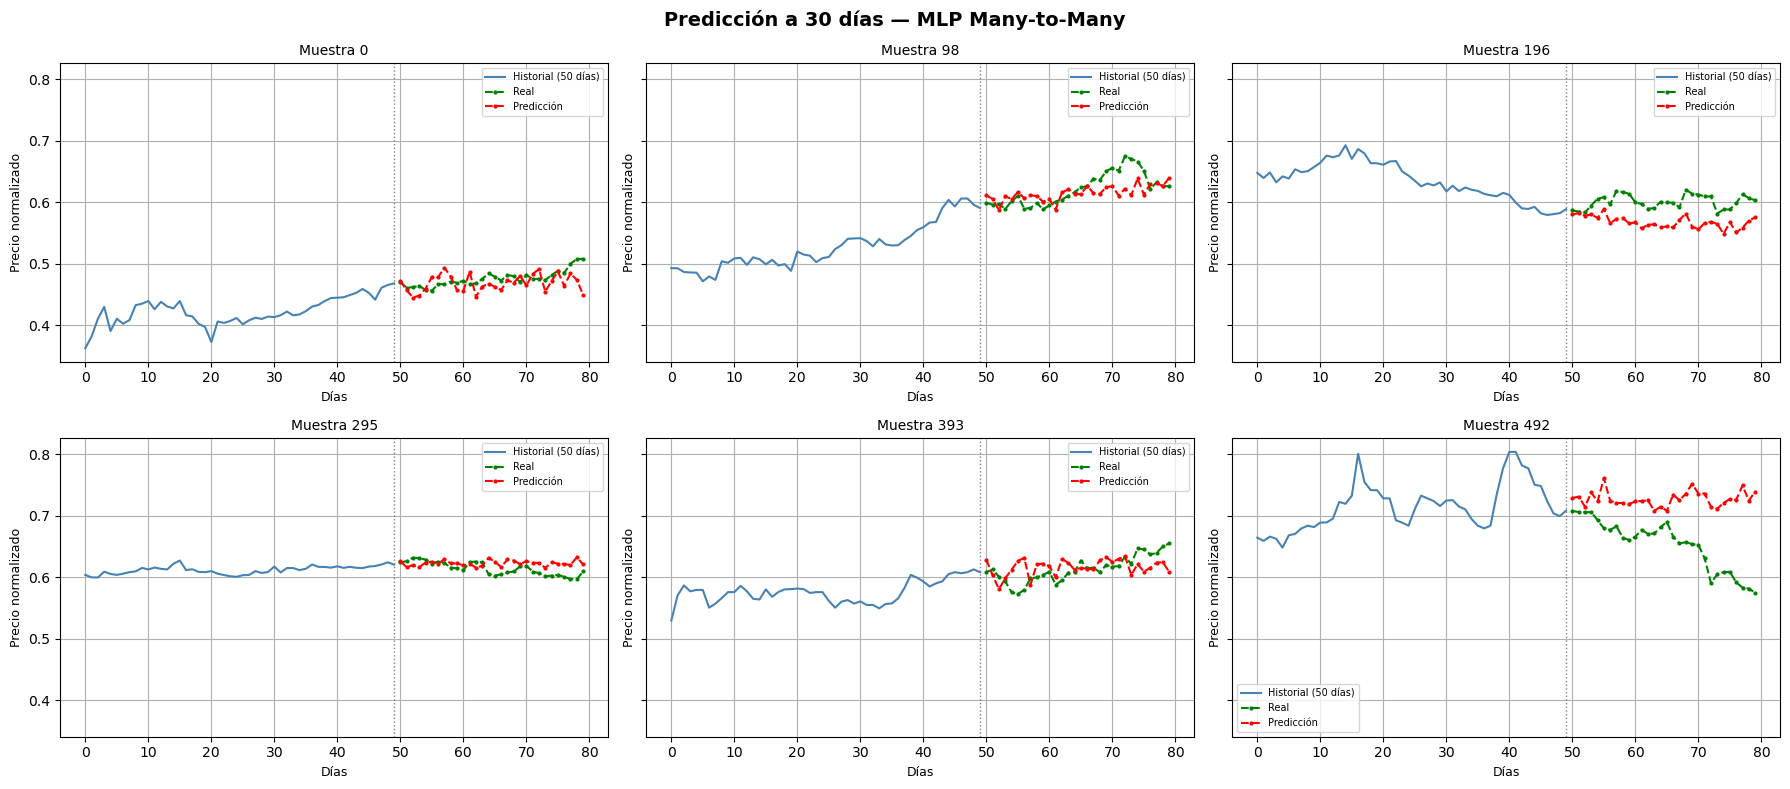

In [164]:
def plot_forecast_m2m(X_test, y_test, y_pred, n_samples=6):
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
    axes = axes.flatten()
    indices = np.linspace(0, len(X_test) - 1, n_samples, dtype=int)

    for i, ix in enumerate(indices):
        ax = axes[i]
        history = X_test[ix, :, 0]
        x_hist  = np.arange(len(history))
        x_fut   = np.arange(len(history), len(history) + len(y_test[ix]))

        ax.plot(x_hist, history,    color='steelblue', label='Historial (50 días)')
        ax.plot(x_fut,  y_test[ix], color='green',  linestyle='--', marker='.', markersize=4, label='Real')
        ax.plot(x_fut,  y_pred[ix], color='red',    linestyle='--', marker='.', markersize=4, label='Predicción')
        ax.axvline(len(history) - 1, color='gray', linestyle=':', linewidth=1)
        ax.set_title(f'Muestra {ix}', fontsize=10)
        ax.set_xlabel('Días', fontsize=9)
        ax.set_ylabel('Precio normalizado', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True)

    plt.suptitle('Predicción a 30 días — MLP Many-to-Many', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_forecast_m2m(X_test_m2m, y_test_m2m, y_pred_m2m)

Como era de esperar, el MSE del modelo many-to-many es mayor que el del many-to-one: predecir 30 días es un problema mucho más difícil que predecir solo el siguiente. Sin embargo, el MLP logra capturar la tendencia general del precio en el horizonte predicho. Las predicciones tienden a suavizarse a medida que aumenta el plazo (los días más lejanos tienen mayor incertidumbre), lo cual es un comportamiento esperado